# Huddle test analysis

Analyses the huddle test batch by batch: every node against the reference (Pegasus + Compact, or the consensus of the 1000 sps / 0 dB / linear-phase nodes), then the registered checks (timing, block convention, firmware, polarity, gain, filter phase, orientation, unit scatter, settings), with result tables (CSV) and figures.

The workflow on the rack is in [README.md](README.md) (`huddle.py start / apply / collect`). Data, results and figures are in `data_dir` from `huddle.yaml`, outside the repository.

**Until real data exist this notebook runs on synthetic batches 1, 5, 6 and 7.** Batch 1 has three known faults, to show that the checks find them: firmware V1.0.7.5ke writes its tags at the block end, V1.0.7.9be is 20 ms late, and unit F2B has its Z channel reversed. Batches 5–7 test the extra settings (GNSS power, low cut including the unknown codes 2 and 10, ADC mode, node MiniSEED, constellations, per-channel gains, minimum phase at every rate, no geophone test); in the synthetic data the low cut shifts phase, low-power mode adds noise, and logged channels 1/2/3 are X/Y/Z.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, ".")
warnings.filterwarnings("ignore")
import pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

import huddle
from huddletest import analysis, checks, config, design, nodes, report

cfg = config.load_settings()
measured = sorted((cfg["data_dir"] / "results").glob("batch_*/measurements.csv"))
DEMO = not measured
if DEMO:
    cfg, _ = huddle.demo("/tmp/huddle_demo", batch=1, batches=[1, 5, 6, 7], verbose=False)
print("demo" if DEMO else "real data", "-", cfg["data_dir"])

demo - /tmp/huddle_demo/data


## 1. Where are we?
Applied and collected units per batch (from `state.json`).

In [2]:
s = nodes.status(cfg)
s.groupby("batch").agg(rows=("row_id", "size"), applied=("applied", lambda x: (x != "").sum()),
                       collected=("collected", lambda x: (x != "").sum()), current=("current", "any"))

,rows,applied,collected,current
batch,,,,
1,24,24,24,False
2,24,0,0,False
3,24,0,0,False
4,24,0,0,False
5,24,24,24,False
6,24,24,24,False
7,24,24,24,True


## 2. Measure
For each collected batch: impacts detected on the reference, then lag, correlation, polarity and amplitude ratio for every node, component and impact, and the horizontal rotation. Lag > 0 means the node's time stamps are late.

In [3]:
collected = [b for b, g in s.groupby("batch") if (g.collected != "").any()]
if not DEMO:
    for b in collected:
        analysis.measure_batch(cfg, b)
meas = pd.concat(pd.read_csv(f) for f in sorted((cfg["data_dir"] / "results").glob("batch_*/measurements.csv")))
meas.head()

,row_id,batch,unit,firmware,sample_rate_sps,block_s,gain_db,filter_phase,orientation_deg,role,...,event_time,lag_s,cc,polarity,amp_ratio,coarse_lag_s,coarse_cc,noise_rms,reference,rotation_deg
0,B1-F1A,1,F1A,V1.0.5.6kp,4000,0.25,0.0,linear,0,rate sweep (Latin square),...,2026-10-20T00:00:47.615000Z,1.853754e-07,1.0,1,0.999928,1.834051e-07,1.0,73.702675,reference station,NaN
1,B1-F1A,1,F1A,V1.0.5.6kp,4000,0.25,0.0,linear,0,rate sweep (Latin square),...,2026-10-20T00:00:47.615000Z,2.017261e-07,1.0,1,0.999952,1.834051e-07,1.0,73.393808,reference station,NaN
2,B1-F1A,1,F1A,V1.0.5.6kp,4000,0.25,0.0,linear,0,rate sweep (Latin square),...,2026-10-20T00:00:47.615000Z,1.845402e-07,1.0,1,0.999984,1.834051e-07,1.0,73.958389,reference station,NaN
3,B1-F1A,1,F1A,V1.0.5.6kp,4000,0.25,0.0,linear,0,rate sweep (Latin square),...,2026-10-20T00:00:59.170000Z,1.887100e-07,1.0,1,0.999927,1.834051e-07,1.0,73.702675,reference station,NaN
4,B1-F1A,1,F1A,V1.0.5.6kp,4000,0.25,0.0,linear,0,rate sweep (Latin square),...,2026-10-20T00:00:59.170000Z,1.725785e-07,1.0,1,0.999953,1.834051e-07,1.0,73.393808,reference station,NaN


## 3. Checks
Every registered check answers one question; its table is also saved as `results/<name>.csv`.

In [4]:
res = checks.run_checks(cfg)
for name, c in checks.REGISTRY.items():
    print(f"{name:18s} {c['question']}")

settings           Did every node record with the planned settings (rate, firmware, gain, leap seconds, GPS)?
time_labels        How do the text time labels relate to GPS time of week on each firmware (offset, 2-s jumps, leap field)?
timing             Absolute timing of each node against the reference (median lag over all impacts).
block_convention   Does a tag mark the start of the block before it? Fit lag = a + b * block length per firmware.
firmware           Do firmware versions differ in timing, amplitude or polarity at the same setting?
polarity           Is every channel positive (FDSN convention) after the x -1 of node_toolbox?
gain               Is the amplitude exactly 10^(gain/20)? Ratio to the 0 dB nodes of the same batch.
filter_phase       Delay and waveform change of the minimum-phase filter against linear phase.
orientation        Horizontal rotation of each node from the data, against the planned rotation.
unit_scatter       Scatter between nodes with identical settin

### Block convention and absolute offset
`lag = a + b × block length` per firmware. `b ≈ 0`: tags mark the start of the block before them (the node_toolbox default). `b ≈ 1`: they mark the block end, and the data are one block late with the default. `a` is the constant clock offset of that firmware.

In [5]:
res["block_convention"]

,firmware,n_rates,rates,offset_a_s,slope_b,residual_rms_s,verdict
0,V1.0.5.6kp,3,"250,1000,4000",6.061586e-07,-6.757129e-07,1.256395e-07,tags mark the block start (default correct)
1,V1.0.5.8ke,3,"125,1000,2000",1.112036e-06,-1.277553e-06,2.131065e-07,tags mark the block start (default correct)
2,V1.0.5.9ke,2,"100,1000",1.558896e-06,-1.547071e-06,7.592201e-09,tags mark the block start (default correct)
3,V1.0.7.5ke,3,"50,500,1000",-3.645038e-01,1.019084e+00,4.045306e-01,tags mark the block END: data one block late w...
4,V1.0.7.8bke,3,"250,1000,4000",6.061586e-07,-6.757129e-07,1.256395e-07,tags mark the block start (default correct)
5,V1.0.7.9be,3,"125,1000,2000",1.279594e-02,8.387898e-04,8.256675e-03,tags mark the block start (default correct)
6,V1.0.8.1be,2,"100,1000",1.558896e-06,-1.547071e-06,7.592201e-09,tags mark the block start (default correct)
7,V1.1.4.2be,3,"50,500,1000",6.606125e-08,-1.524581e-07,1.304562e-07,tags mark the block start (default correct)


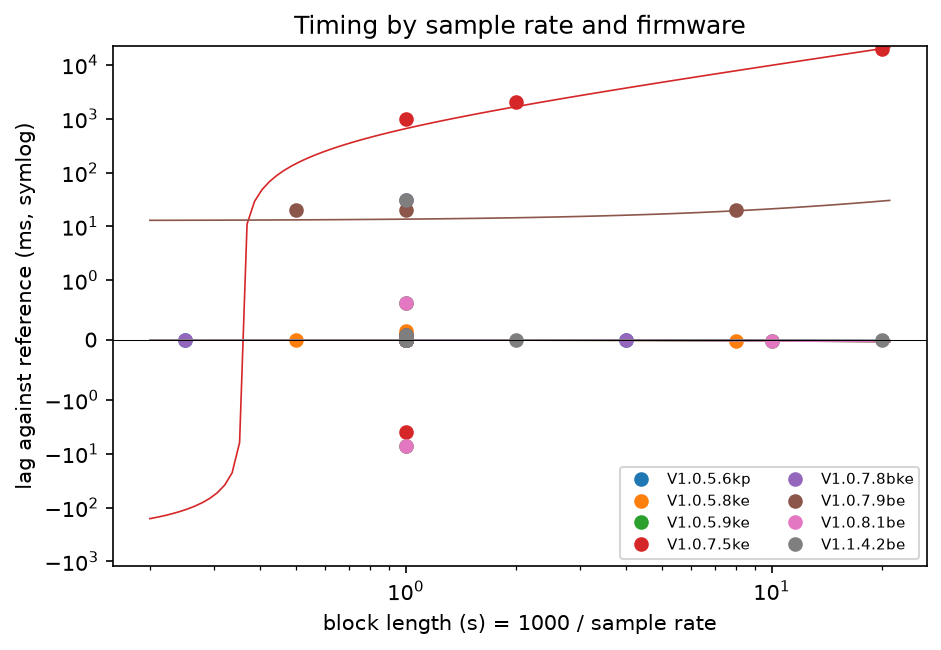

In [6]:
report.lag_vs_block(res, cfg); display(Image(cfg["data_dir"] / "results/figures/lag_vs_block.png"))

### Timing per node

In [7]:
res["timing"][["row_id", "firmware", "sample_rate_sps", "filter_phase", "lag_s", "lag_mad_s", "cc", "n_events"]]

,row_id,firmware,sample_rate_sps,filter_phase,lag_s,lag_mad_s,cc,n_events
0,B1-F1A,V1.0.5.6kp,4000,linear,1.822591e-07,2.510301e-09,1.000000,14
1,B1-F1B,V1.0.5.6kp,250,linear,-2.160436e-06,4.003474e-08,0.999995,14
2,B1-F1C,V1.0.5.6kp,1000,linear,1.766561e-08,1.192183e-08,1.000000,14
3,B1-F2A,V1.0.5.8ke,2000,linear,1.340882e-07,5.962425e-09,1.000000,14
4,B1-F2B,V1.0.5.8ke,125,linear,-9.132614e-06,4.504130e-08,0.999911,14
...,...,...,...,...,...,...,...,...
83,B7-F7B,V1.0.8.1be,250,minimum,6.338263e-03,2.084068e-08,0.992379,14
84,B7-F7C,V1.0.8.1be,1000,linear,-7.295369e-03,9.879927e-06,0.960477,14
85,B7-F8A,V1.1.4.2be,125,minimum,1.797410e-02,1.518136e-07,0.995405,14
86,B7-F8B,V1.1.4.2be,2000,minimum,1.753839e-03,1.736702e-08,0.998258,14


### Polarity
After node_toolbox's ×−1 every channel should be +1 (FDSN convention).

In [8]:
res["polarity"]

component,row_id,unit,firmware,E,N,Z,all_positive
0,B1-F1A,F1A,V1.0.5.6kp,1.0,1.0,1.0,True
1,B1-F1B,F1B,V1.0.5.6kp,1.0,1.0,1.0,True
2,B1-F1C,F1C,V1.0.5.6kp,1.0,1.0,1.0,True
3,B1-F2A,F2A,V1.0.5.8ke,1.0,1.0,1.0,True
4,B1-F2B,F2B,V1.0.5.8ke,1.0,1.0,-1.0,False
...,...,...,...,...,...,...,...
79,B7-F7A,F7A,V1.0.8.1be,1.0,1.0,1.0,True
80,B7-F7B,F7B,V1.0.8.1be,1.0,1.0,1.0,True
81,B7-F8A,F8A,V1.1.4.2be,1.0,1.0,1.0,True
82,B7-F8B,F8B,V1.1.4.2be,1.0,1.0,1.0,True


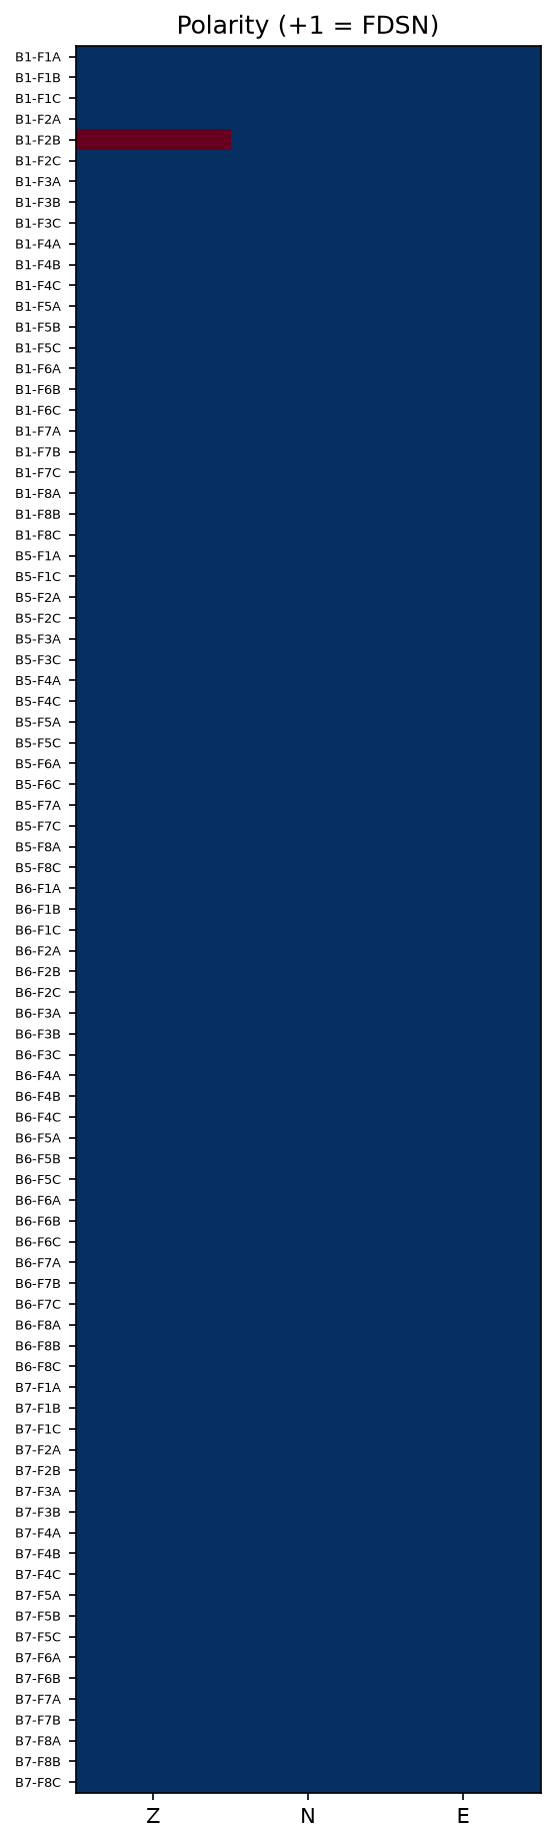

In [9]:
report.polarity_map(res, cfg); display(Image(cfg["data_dir"] / "results/figures/polarity.png"))

### Gain, filter phase, orientation, scatter between identical nodes

In [10]:
display(res["gain"]); display(res["filter_phase"]); display(res["orientation"]); display(res["unit_scatter"])

,batch,unit,firmware,gain_db,amp_ratio,error_pct
0,1,F1C,V1.0.5.6kp,0.0,1.0,6.439294e-13
1,1,F2C,V1.0.5.8ke,0.0,1.0,6.439294e-13
2,1,F3A,V1.0.5.9ke,0.0,1.0,6.439294e-13
3,1,F3C,V1.0.5.9ke,0.0,1.0,6.439294e-13
4,1,F4C,V1.0.7.5ke,0.0,1.0,6.439294e-13
5,1,F5C,V1.0.7.8bke,0.0,1.0,6.439294e-13
6,1,F6C,V1.0.7.9be,0.0,1.0,-1.199041e-12
7,1,F7B,V1.0.8.1be,0.0,1.0,6.439294e-13
8,1,F7C,V1.0.8.1be,0.0,1.0,6.439294e-13
9,1,F8C,V1.1.4.2be,0.0,1.0,6.439294e-13


,row_id,unit,firmware,sample_rate_sps,lag_s,linear_lag_s,delay_s,cc
36,B7-F1A,F1A,V1.0.5.6kp,50,0.044067,9.999997e+00,-9.955931,0.983719
37,B7-F1B,F1B,V1.0.5.6kp,1000,0.003935,1.469832e-08,0.003935,0.991301
39,B7-F2A,F2A,V1.0.5.8ke,100,0.021513,-1.391181e-05,0.021527,0.998932
40,B7-F2B,F2B,V1.0.5.8ke,1000,0.003935,1.469832e-08,0.003935,0.991301
41,B7-F3A,F3A,V1.0.5.9ke,125,0.017974,9.990877e-03,0.007983,0.995405
42,B7-F3B,F3B,V1.0.5.9ke,1000,0.003935,1.469832e-08,0.003935,0.991301
43,B7-F4A,F4A,V1.0.7.5ke,250,0.006338,-2.160436e-06,0.006340,0.992379
44,B7-F4B,F4B,V1.0.7.5ke,4000,0.000414,1.822591e-07,0.000414,0.999903
45,B7-F5A,F5A,V1.0.7.8bke,500,0.003107,9.999995e-01,-0.996892,0.997966
46,B7-F5B,F5B,V1.0.7.8bke,50,0.044067,9.999997e+00,-9.955931,0.983719


,row_id,unit,firmware,orientation_deg,rotation_deg,error_deg
42,B1-F1A,F1A,V1.0.5.6kp,0,0.0,0.0
85,B1-F1B,F1B,V1.0.5.6kp,0,0.0,0.0
128,B1-F1C,F1C,V1.0.5.6kp,0,0.0,0.0
171,B1-F2A,F2A,V1.0.5.8ke,0,0.0,0.0
214,B1-F2B,F2B,V1.0.5.8ke,0,0.0,0.0
...,...,...,...,...,...,...
3955,B7-F7B,F7B,V1.0.8.1be,0,0.0,0.0
3998,B7-F7C,F7C,V1.0.8.1be,0,358.0,-2.0
4041,B7-F8A,F8A,V1.1.4.2be,0,0.0,0.0
4084,B7-F8B,F8B,V1.1.4.2be,0,0.0,0.0


,batch,sample_rate_sps,gain_db,filter_phase,orientation_deg,units,firmwares,lag_std_s,lag_range_s,amp_std
0,1,50,0.0,linear,0,2,2,14.142136,20.000001,0.000000e+00
1,1,100,0.0,linear,0,2,2,0.000000,0.000000,0.000000e+00
2,1,125,0.0,linear,0,2,2,0.014142,0.020000,1.401851e-06
3,1,250,0.0,linear,0,2,2,0.000000,0.000000,0.000000e+00
4,1,500,0.0,linear,0,2,2,1.414214,2.000000,0.000000e+00
5,1,1000,0.0,linear,0,10,8,0.315588,1.000000,5.816175e-15
6,1,2000,0.0,linear,0,2,2,0.014142,0.020000,4.553268e-15
7,1,4000,0.0,linear,0,2,2,0.000000,0.000000,0.000000e+00
8,5,1000,0.0,linear,0,8,8,0.000000,0.000000,0.000000e+00
9,6,1000,0.0,linear,0,4,4,0.000000,0.000000,0.000000e+00


### Extra settings (batches 5–7)
Each node with a non-default setting against reference-setting nodes of the same firmware (same batch if possible, else other batches, so firmware offsets cancel): lag difference, lag scatter, correlation, amplitude and noise ratio.

In [11]:
res["factors"]

,factor,level,row_id,unit,firmware,compared_with,lag_diff_s,lag_mad_s,ref_lag_mad_s,cc,ref_cc,amp_ratio,noise_ratio
0,gnss_mode,always,B5-F1A,F1A,V1.0.5.6kp,"same firmware, same batch",0.000000e+00,1.357987e-08,1.357987e-08,1.000000,1.000000,1.000000,1.000000
1,gnss_mode,always,B5-F2A,F2A,V1.0.5.8ke,"same firmware, same batch",0.000000e+00,1.357987e-08,1.357987e-08,1.000000,1.000000,1.000000,1.000000
2,gnss_mode,always,B5-F3A,F3A,V1.0.5.9ke,"same firmware, same batch",0.000000e+00,1.357987e-08,1.357987e-08,1.000000,1.000000,1.000000,1.000000
3,gnss_mode,always,B5-F4A,F4A,V1.0.7.5ke,"same firmware, same batch",0.000000e+00,1.357987e-08,1.357987e-08,1.000000,1.000000,1.000000,1.000000
4,gnss_mode,always,B5-F5A,F5A,V1.0.7.8bke,"same firmware, same batch",0.000000e+00,1.357987e-08,1.357987e-08,1.000000,1.000000,1.000000,1.000000
5,gnss_mode,always,B5-F6A,F6A,V1.0.7.9be,"same firmware, same batch",0.000000e+00,1.357987e-08,1.357987e-08,1.000000,1.000000,1.000000,1.000000
6,gnss_mode,always,B5-F7A,F7A,V1.0.8.1be,"same firmware, same batch",0.000000e+00,1.357987e-08,1.357987e-08,1.000000,1.000000,1.000000,1.000000
7,gnss_mode,always,B5-F8A,F8A,V1.1.4.2be,"same firmware, same batch",0.000000e+00,1.357987e-08,1.357987e-08,1.000000,1.000000,1.000000,1.000000
8,gnss_system,gps+beidou,B6-F4C,F4C,V1.0.7.5ke,"same firmware, other batches",-5.000000e-01,1.299944e-08,1.275085e-08,1.000000,1.000000,0.999999,1.012138
9,gnss_system,gps+beidou,B6-F8C,F8C,V1.1.4.2be,"same firmware, other batches",-1.890778e-08,1.299944e-08,1.275085e-08,1.000000,1.000000,0.999999,1.012138


### Channel mapping
Units with 0, 12 and 24 dB on logged channels 1, 2 and 3: the amplitude of each component, relative to 0 dB nodes, shows which channel it is.

In [12]:
res["channel_mapping"]

,row_id,unit,firmware,E_gain_db,E_is_channel,N_gain_db,N_is_channel,Z_gain_db,Z_is_channel,mapping,unique
0,B6-F1A,F1A,V1.0.5.6kp,12.0,2,0.0,1,24.0,3,"Ch1=X, Ch2=Y, Ch3=Z",True
1,B6-F2A,F2A,V1.0.5.8ke,12.0,2,0.0,1,24.0,3,"Ch1=X, Ch2=Y, Ch3=Z",True
2,B6-F3A,F3A,V1.0.5.9ke,12.0,2,0.0,1,24.0,3,"Ch1=X, Ch2=Y, Ch3=Z",True
3,B6-F4A,F4A,V1.0.7.5ke,12.0,2,0.0,1,24.0,3,"Ch1=X, Ch2=Y, Ch3=Z",True
4,B6-F5A,F5A,V1.0.7.8bke,12.0,2,0.0,1,24.0,3,"Ch1=X, Ch2=Y, Ch3=Z",True
5,B6-F6A,F6A,V1.0.7.9be,12.0,2,0.0,1,24.0,3,"Ch1=X, Ch2=Y, Ch3=Z",True
6,B6-F7A,F7A,V1.0.8.1be,12.0,2,0.0,1,24.0,3,"Ch1=X, Ch2=Y, Ch3=Z",True
7,B6-F8A,F8A,V1.1.4.2be,12.0,2,0.0,1,24.0,3,"Ch1=X, Ch2=Y, Ch3=Z",True


### Settings actually recorded
Firmware, sample rate and serial from the DLD header (or node MiniSEED); sample rate, per-channel gains, anti-alias filter, low cut, ADC mode and GNSS power mode echoed in the log, compared with the plan; leap-second field, longest time without GPS synchronisation and 2-s label jumps.

In [13]:
res["settings"]

,row_id,batch,unit,planned_firmware,planned_rate,planned_gain,serial,firmware,rate,leap_seconds,...,log_channel_2_gain,log_channel_3_gain,log_anti_alias_filter_type,log_low_cutter_filter,log_gps_power_mode,log_adc_lp_mode,log_fifo_storage_mode,ok,problem,storage
0,B1-F1A,1,F1A,V1.0.5.6kp,4000,0.0,999000001,V1.0.5.6kp,4000.0,18.0,...,0.0,0.0,Linear,0.0,CycleOff,0.0,1.0,True,,NaN
1,B1-F1B,1,F1B,V1.0.5.6kp,250,0.0,999000002,V1.0.5.6kp,250.0,18.0,...,0.0,0.0,Linear,0.0,CycleOff,0.0,1.0,True,,NaN
2,B1-F1C,1,F1C,V1.0.5.6kp,1000,0.0,999000003,V1.0.5.6kp,1000.0,18.0,...,0.0,0.0,Linear,0.0,CycleOff,0.0,1.0,True,,NaN
3,B1-F2A,1,F2A,V1.0.5.8ke,2000,0.0,999000004,V1.0.5.8ke,2000.0,18.0,...,0.0,0.0,Linear,0.0,CycleOff,0.0,1.0,True,,NaN
4,B1-F2B,1,F2B,V1.0.5.8ke,125,0.0,999000005,V1.0.5.8ke,125.0,18.0,...,0.0,0.0,Linear,0.0,CycleOff,0.0,1.0,True,,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,B7-F7B,7,F7B,V1.0.8.1be,250,0.0,999000020,V1.0.8.1be,250.0,18.0,...,0.0,0.0,Minimum,0.0,CycleOff,0.0,1.0,True,,NaN
92,B7-F7C,7,F7C,V1.0.8.1be,1000,0.0,999000021,V1.0.8.1be,1000.0,18.0,...,0.0,0.0,Linear,10.0,CycleOff,0.0,1.0,True,,NaN
93,B7-F8A,7,F8A,V1.1.4.2be,125,0.0,999000022,V1.1.4.2be,125.0,18.0,...,0.0,0.0,Minimum,0.0,CycleOff,0.0,1.0,True,,NaN
94,B7-F8B,7,F8B,V1.1.4.2be,2000,0.0,999000023,V1.1.4.2be,2000.0,18.0,...,0.0,0.0,Minimum,0.0,CycleOff,0.0,1.0,True,,NaN


### Time labels per firmware
Label − GPS time of week at the start and end of each file, files with a 2-s jump, the leap field and the longest time without GPS sync. On real nodes this differs between firmware versions; in the synthetic data it does not.

In [14]:
res["time_labels"]

,firmware,nodes,leap_field,label_minus_tow_first_s,label_minus_tow_last_s,files_with_jump,max_sync_age_s
0,V1.0.5.6kp,11,[18.0],[-1.0],"[-1.75, -1.0]",0,59.0
1,V1.0.5.8ke,12,[18.0],[-1.0],"[-1.5, -1.0]",0,59.0
2,V1.0.5.9ke,11,[18.0],[-1.0],[-1.0],0,59.0
3,V1.0.7.5ke,12,[18.0],[-1.0],"[-1.75, -1.0]",0,59.0
4,V1.0.7.8bke,11,[18.0],[-1.0],"[-1.75, -1.0]",0,59.0
5,V1.0.7.9be,12,[18.0],[-1.0],"[-1.5, -1.0]",0,59.0
6,V1.0.8.1be,11,[18.0],[-1.0],"[-1.75, -1.0]",0,59.0
7,V1.1.4.2be,12,[18.0],[-1.0],"[-1.5, -1.0]",0,59.0


## 4. Adding a check

A check is a function of the measurement table that returns a table. Register it with `@checks.check(name, question)`; `run_checks` then runs it with all the others. Put permanent checks in `huddletest/checks.py`.

In [15]:
@checks.check("event_count", "Did every node see every impact?")
def event_count(meas, ctx):
    z = meas[meas.component == "Z"]
    n = z.groupby("row_id").event_time.nunique()
    return n.rename("impacts").reset_index().assign(all_seen=lambda d: d.impacts == d.impacts.max())

checks.run_checks(cfg, names=["event_count"])["event_count"].head()

,row_id,impacts,all_seen
0,B1-F1A,14,True
1,B1-F1B,14,True
2,B1-F1C,14,True
3,B1-F2A,14,True
4,B1-F2B,14,True


## 5. The next batch

Batches 1–4 are the Latin square, batches 5–7 test the extra settings. The guided run of the real test is `sand_box_huddle_test/run_huddle.py`. Further batches are proposed from what is covered and what is still uncertain: `optimised` picks, for each unit, the one-factor change from the reference setting that covers its firmware least so far, preferring (firmware, rate) cells with the largest lag spread; `random` draws from the same candidates. Two units always keep the reference setting. With `write=True` (or `huddle.py propose`) the rows are appended to the matrix, and `make-xml`, `apply`, `collect` and this notebook work on them unchanged.

In [16]:
design.propose_batch(cfg, "optimised", write=False)[["row_id", "sample_rate_sps", "gain_db", "filter_phase", "orientation_deg", "role"]]

,row_id,sample_rate_sps,gain_db,filter_phase,orientation_deg,role
0,B8-F1A,250,0,minimum,0,optimised
1,B8-F1B,1000,36,linear,0,optimised
2,B8-F1C,1000,12,linear,0,optimised
3,B8-F2A,125,0,minimum,0,optimised
4,B8-F2B,1000,36,linear,0,optimised
5,B8-F2C,1000,24,linear,0,optimised
6,B8-F3A,100,0,minimum,0,optimised
7,B8-F3B,1000,18,linear,0,optimised
8,B8-F3C,1000,6,linear,0,optimised
9,B8-F4A,1000,6,linear,0,optimised
